### MusicBrainz dataset - aggregation functions

We note that the original aggregation function has asymptotic decay that affects our actual matches. We explore different functions for aggregation here that might provide better scores.

This is NOT the same as a confidence layer that is relational to other possible matches. We consider that later.

In [1]:
import pandas as pd
from splink import Linker, DuckDBAPI
import pyarrow as pa
import pyarrow.parquet as pq
import os

import sys

import matplotlib.pyplot as plt
import seaborn as sns

DF_PATH = os.path.join("..", "..", "public_datasets", "musicbrainz-20-A01.csv.dapo")
target_dir = os.path.dirname(DF_PATH)
df1 = pd.read_parquet(os.path.join(target_dir, "cleaned_music3.parq"))
df2 = pd.read_parquet(os.path.join(target_dir, "cleaned_music5.parq"))

predicts_file_path = "../local_predicts/music_predictions.parquet"
predicts_pd = pd.read_parquet(predicts_file_path)

In [2]:
df1

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,6,5,1,3,49425110MB-01,6.0,Try (acoustic),None,Neil Young,"2008-02-15: Le Grand Rex, Paris, France",None,English,uai_838,NaN,None
1,21,3118,2,3,4763264MB-01,6.0,Cállate,4.367,Wisin & Yandel,Los vaqueros: el regreso: Deluxe Edition,'11,Spanish,uai_13,262020.0,"[1911, 2011]"
2,25,5893,2,3,50116112MB-01,9.0,Fish Tail Blues,3.085,Jelly Roll Morton,The King & Mister Jelly Lord,'89,English,uai_604,185100.0,"[1989, 2089]"
3,39,519,3,3,5235450MB-01,13.0,Mu sõber tuul,4.567,Laine,Uus Laine,'00,Estonian,uai_5829,274020.0,"[1900, 2000]"
4,44,25,1,3,23433710MB-01,2.0,Fried Bananas,12.3,Dexter Gordon,Live at the Amsterdam Paradiso,'94,English,uai_230,738000.0,"[1994, 2094]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,19366,9994,1,3,11546013MB-01,12.0,Steal Away,4.424,Dublin City Ramblers,Flight of Earls,None,English,uai_567,265440.0,None
3922,19368,9995,1,3,14504822MB-01,4.0,I Am What I Am (live at Abbey Road),4.374,Mark Owen,Clementine,None,English,uai_5985,262440.0,None
3923,19370,9996,1,3,70007517MB-01,9.0,Sukkana alas!,2.928,Popeda,Kans'an Popeda,'05,Finnish,uai_2780,175680.0,"[1905, 2005]"
3924,19372,9998,1,3,37406511MB-01,5.0,The Pressure of Pitching Doves,1.85,Buddy Wakefield,Run on Anything,None,English,uai_5179,111000.0,None


In [3]:
df2

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options
0,4,3,1,5,4489993,10.0,Your Grace,unk.,Kathy Troccoli,Comfort,2005,English,uai_4269,NaN,[2005]
1,5,4,1,5,10339621,2.0,Well You Needn't,321266,Ernie Stadler Jazz Quintet,First Down,2010,English,uai_1397,321266.0,[2010]
2,9,7,1,5,10992441,9.0,Just Like Tom Thumb's Blues (live),462000,Wendy Saddington,"Blues Women Anthology, Volume 7",2007,English,uai_299,462000.0,[2007]
3,10,6842,4,5,15761001,4.0,Στα καμένα,195000,Λαυρέντης Μαχαιρίίτσας,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",1997,Greek,uai_4401,195000.0,[1997]
4,11,5568,2,5,855829,6.0,None,188400,Anathema,Alternative 4,1998,English,uai_4117,188400.0,[1998]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3823,19319,2898,5,5,3435746,1.0,"Inside the Dream Syndicate, Volume I: Day of N...",1854000,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...",2000,English,uai_517,1854000.0,[2000]
3824,19328,9974,1,5,9839750,4.0,Wedding,334000,Charbel Rouuhana,fma Festival du Monde Arabe de Montréal 10ième...,None,French,uai_2335,334000.0,None
3825,19332,4851,2,5,12382038,9.0,"Just You, Just Me",296000,Sonny Stitt & Barry Harris,The Complete Late Quartets,2010,English,uai_1870,296000.0,[2010]
3826,19333,4920,2,5,6817983,5.0,Nightmare,None,Icos,Fragments of Sirens,None,English,uai_4087,NaN,None


In [4]:
predicts_pd

,match_weight,match_probability,source_dataset_l,source_dataset_r,CID_l,CID_r,artist_l,artist_r,gamma_artist,bf_artist,...,bf_year_options,number_l,number_r,gamma_number,bf_number,CTID_l,CTID_r,uai_l,uai_r,match_key
0,49.089737,1.000000e+00,__splink__input_table_0,__splink__input_table_1,7,7,Wendy Saddington,Wendy Saddington,2,4602.444889,...,24.623950,9.0,9.0,1,16.863659,4,1,uai_299,uai_299,0
1,47.640098,1.000000e+00,__splink__input_table_0,__splink__input_table_1,6842,6842,Λαυρέντης Μαχαιρίτσας,Λαυρέντης Μαχαιρίίτσας,1,1685.015295,...,24.623950,4.0,4.0,1,16.863659,2,4,uai_1893,uai_4401,1
2,45.633213,1.000000e+00,__splink__input_table_0,__splink__input_table_1,3385,3385,Diana Ross & Lionel Richie,Diana Ross & Lionel Richie,2,4602.444889,...,24.623950,5.0,5.0,1,16.863659,2,4,uai_532,uai_532,0
3,33.451364,1.000000e+00,__splink__input_table_0,__splink__input_table_1,7301,7301,Doors,The Doros,0,0.090234,...,24.623950,13.0,13.0,1,16.863659,1,3,uai_5494,uai_5014,1
4,-32.341265,1.837846e-10,__splink__input_table_0,__splink__input_table_1,4627,4960,12 Moons,Ozzy Osbourne,0,0.090234,...,0.042158,4.0,4.0,1,16.863659,1,2,uai_5448,uai_2132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,-36.203500,1.263748e-11,__splink__input_table_0,__splink__input_table_1,5386,9761,Wolfgang Amadeus Mozart,Joseph Haydn,0,0.090234,...,1.000000,7.0,7.0,1,16.863659,1,1,uai_348,uai_174,1
1467,-11.600156,3.220069e-04,__splink__input_table_0,__splink__input_table_1,8953,704,Пётр Ильичч Чайковский,Wolfgang Amadeus Mozart,0,0.090234,...,1.000000,3.0,3.0,1,16.863659,2,2,uai_4755,uai_348,1
1468,-16.867299,8.364374e-06,__splink__input_table_0,__splink__input_table_1,397,7828,Johann Sebastian Bach,Johann Sebastian Bach,2,4602.444889,...,0.032130,8.0,8.0,1,16.863659,1,1,uai_14,uai_14,0
1469,-20.565127,6.445842e-07,__splink__input_table_0,__splink__input_table_1,1033,8380,Wolfgang Amadeus Mozart,Wolfgang Amadeus Mozart,2,4602.444889,...,1.000000,6.0,6.0,1,16.863659,1,1,uai_348,uai_348,0


#### Initial benchmark: Basic aggregation via an equally-weighted probability function

In [5]:
left_counts  = df1["uai"].value_counts()   # Series: id → frequency in df1
right_counts = df2["uai"].value_counts()   # Series: id → frequency in df2

agg_df = (
    predicts_pd[
        ['uai_l', 'uai_r','match_probability', 'artist_l', 'artist_r']
    ]
    .groupby(['uai_l', 'uai_r'], as_index=False, dropna=False)
    .agg({
        'match_probability': sum,
        'artist_l': 'first',
        'artist_r': 'first'
    })
)

agg_df

/tmp/ipykernel_1312877/2750937874.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({


,uai_l,uai_r,match_probability,artist_l,artist_r
0,uai_0,uai_0,1.000000,int21,int21
1,uai_1,uai_1,1.000000,Darude,Darude
2,uai_10,uai_10,1.000000,Alfredo Gutierrez,Alfredo Gutierrez
3,uai_100,uai_100,1.000000,Nucleus Torn,Nucleus Torn
4,uai_1000,uai_1000,1.000000,Real Cool Traders,Real Cool Traders
...,...,...,...,...,...
1318,uai_994,uai_994,1.000000,Broadway Quartet feat. Charles Harrison,Broadway Quartet feat. Charles Harrison
1319,uai_995,uai_995,1.000000,Cymbals,Cymbals
1320,uai_996,uai_996,1.000000,Saft,Saft
1321,uai_997,uai_997,0.999185,"Karl Gerhard, Folkans Orkester","Karl Gerhard, Folkans Orkester"


In [6]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["uai_l", "uai_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="uai_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="uai_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
# ---------------------------------------------------------------------------
# 4️⃣ Join the aggregated probabilities using an INNER join to drop NaNs
# ---------------------------------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["uai_l", "uai_r"],
    how="inner" # Drops any unobserved pairs instantly
)

# Calculate your normalized metrics only on the pairs that survived
norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df


,uai_l,uai_r,left_count,right_count,pair_size,match_probability,artist_l,artist_r,norm_match_prob
0,uai_14,uai_14,22,24,528,1.094172e+01,Johann Sebastian Bach,Johann Sebastian Bach,2.072296e-02
1,uai_14,uai_348,22,12,264,1.304353e-11,Johann Sebastian Bach,Wolfgang Amadeus Mozart,4.940732e-14
2,uai_14,uai_5471,22,1,22,5.103886e-09,Johann Sebastian Bach,AvisonEnsemble,2.319948e-10
3,uai_348,uai_14,13,24,312,2.527497e-11,Wolfgang Amadeus Mozart,Johann Sebastian Bach,8.100952e-14
4,uai_348,uai_348,13,12,156,2.000587e+00,Wolfgang Amadeus Mozart,Wolfgang Amadeus Mozart,1.282427e-02
...,...,...,...,...,...,...,...,...,...
1318,uai_1510,uai_4327,1,1,1,2.964029e-13,Gloria Gaynor,Oneida,2.964029e-13
1319,uai_711,uai_45,1,1,1,2.964029e-13,Ray Charles,Sixpence None the Richer,2.964029e-13
1320,uai_711,uai_711,1,1,1,1.000000e+00,Ray Charles,Ray Charles,1.000000e+00
1321,uai_658,uai_658,1,1,1,1.000000e+00,Todd Thibaud,Todd Thibaud,1.000000e+00


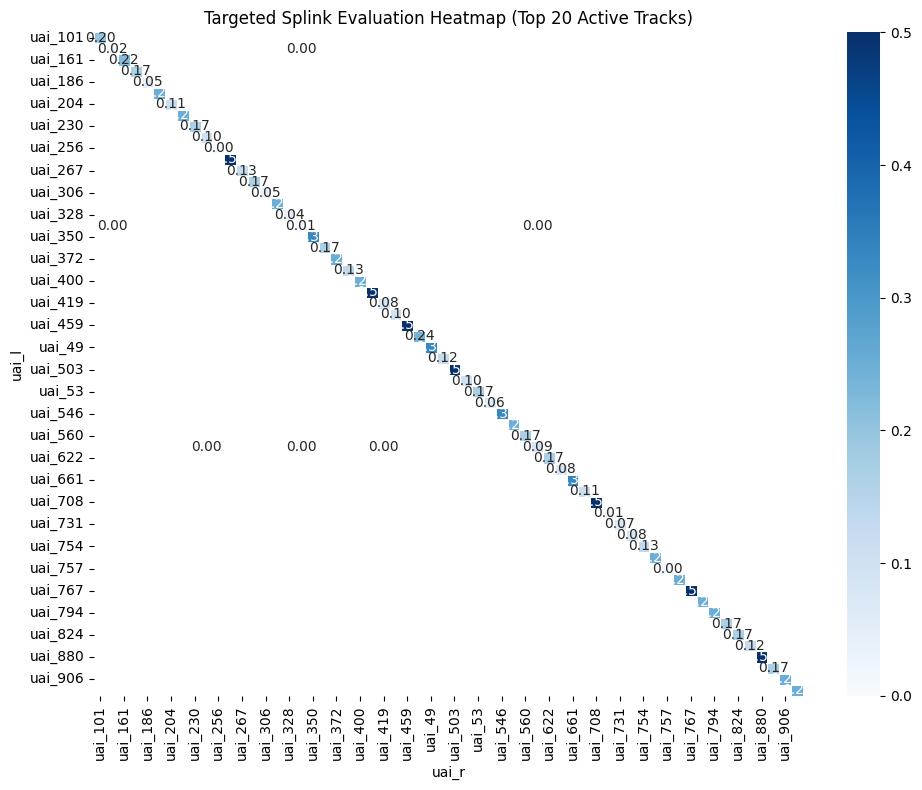

In [7]:
# 1. Identify the most active ground truth track IDs
top_entities = norm_df[norm_df['uai_l'] == norm_df['uai_r']].nlargest(60, 'pair_size')['uai_l']

# 2. Slice the matrix strictly to interactions involving these top entities
dense_subset = norm_df[norm_df['uai_l'].isin(top_entities) & norm_df['uai_r'].isin(top_entities)]

# 3. Pivot ONLY this small dense subset (Safe from memory drops)
mat_sub = dense_subset.pivot(index='uai_l', columns='uai_r', values='norm_match_prob')

# 4. Render the targeted heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    mat_sub,
    cmap='Blues',           # Sequential map works better here since numbers are 0 to 1
    mask=mat_sub.isna(),
    linewidths=.5,
    annot=True,             # Write numbers inside cells for explicit tracking
    fmt=".2f"
)
plt.title('Targeted Splink Evaluation Heatmap (Top 20 Active Tracks)')
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import pandas as pd

# 1. Establish the absolute baseline of true connections in your ground truth
# (Every unique track ID matching with itself)
total_possible_true_matches = len(agg_df[agg_df['uai_l'] == agg_df['uai_r']])

# 2. Generate a spectrum of threshold checkpoints
thresholds = np.linspace(0.00, 0.95, 40)
pr_results = []

for t in thresholds:
    # Flag predicted pairs that clear the current normalization threshold
    predicted_pairs = norm_df[norm_df['norm_match_prob'] >= t]
    
    # Calculate True Positives (On the diagonal)
    tp = len(predicted_pairs[predicted_pairs['uai_l'] == predicted_pairs['uai_r']])
    
    # Calculate False Positives (Off the diagonal)
    fp = len(predicted_pairs[predicted_pairs['uai_l'] != predicted_pairs['uai_r']])
    
    # Deriving structural evaluation metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / total_possible_true_matches if total_possible_true_matches > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    pr_results.append({
        'Threshold': round(t, 2),
        'True_Positives': tp,
        'False_Positives': fp,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1_Score': round(f1, 4)
    })

# Convert to tracking DataFrame for analysis
pr_curve_df = pd.DataFrame(pr_results)
display(pr_curve_df)


,Threshold,True_Positives,False_Positives,Precision,Recall,F1_Score
0,0.00,934,389,0.7060,1.0000,0.8276
1,0.02,911,267,0.7733,0.9754,0.8627
2,0.05,907,265,0.7739,0.9711,0.8613
3,0.07,903,265,0.7731,0.9668,0.8592
4,0.10,899,261,0.7750,0.9625,0.8586
5,0.12,894,261,0.7740,0.9572,0.8559
6,0.15,889,260,0.7737,0.9518,0.8536
7,0.17,879,260,0.7717,0.9411,0.8480
8,0.19,879,258,0.7731,0.9411,0.8489
9,0.22,878,258,0.7729,0.9400,0.8483


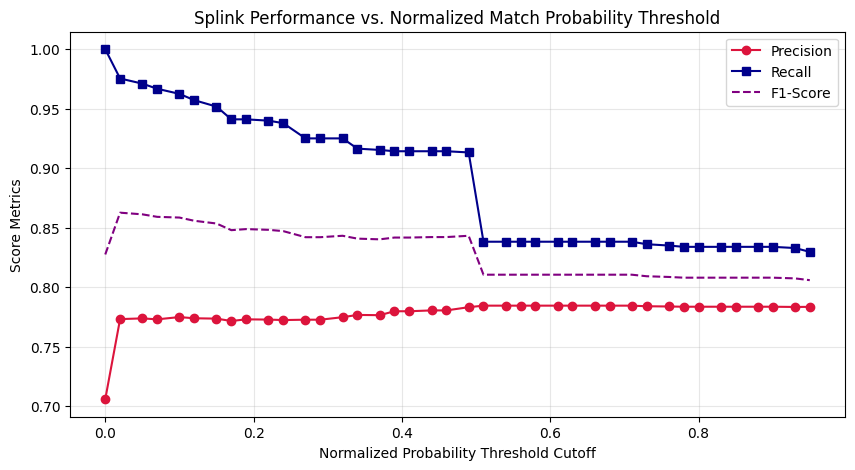

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Precision'], label='Precision', marker='o', color='crimson')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['Recall'], label='Recall', marker='s', color='darkblue')
plt.plot(pr_curve_df['Threshold'], pr_curve_df['F1_Score'], label='F1-Score', linestyle='--', color='purple')

plt.title('Splink Performance vs. Normalized Match Probability Threshold')
plt.xlabel('Normalized Probability Threshold Cutoff')
plt.ylabel('Score Metrics')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [10]:
# We try to reason out why we might see the drop in metrics

global_matches = norm_df[norm_df["uai_l"] == norm_df["uai_r"]]
global_matches.sort_values(by="pair_size", ascending=False)

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,artist_l,artist_r,norm_match_prob
0,uai_14,uai_14,22,24,528,10.941720,Johann Sebastian Bach,Johann Sebastian Bach,0.020723
4,uai_348,uai_348,13,12,156,2.000587,Wolfgang Amadeus Mozart,Wolfgang Amadeus Mozart,0.012824
7,uai_718,uai_718,12,12,144,2.000004,[unknown],[unknown],0.013889
20,uai_306,uai_306,7,6,42,2.000000,Georg Friedrich Händel,Georg Friedrich Händel,0.047619
17,uai_731,uai_731,7,6,42,3.000009,Frédéric Chopin,Frédéric Chopin,0.071429
...,...,...,...,...,...,...,...,...,...
518,uai_207,uai_207,1,1,1,1.000000,Kwest Tha Madd Lad,Kwest Tha Madd Lad,1.000000
519,uai_737,uai_737,1,1,1,1.000000,Manuel Escorcio,Manuel Escorcio,1.000000
521,uai_982,uai_982,1,1,1,1.000000,Rockwell,Rockwell,1.000000
522,uai_925,uai_925,1,1,1,1.000000,Klaus Schulze,Klaus Schulze,1.000000


In [11]:
global_non_matches = norm_df[norm_df["uai_l"] != norm_df["uai_r"]]
global_non_matches.sort_values(by="pair_size", ascending=False)

,uai_l,uai_r,left_count,right_count,pair_size,match_probability,artist_l,artist_r,norm_match_prob
3,uai_348,uai_14,13,24,312,2.527497e-11,Wolfgang Amadeus Mozart,Johann Sebastian Bach,8.100952e-14
1,uai_14,uai_348,22,12,264,1.304353e-11,Johann Sebastian Bach,Wolfgang Amadeus Mozart,4.940732e-14
10,uai_57,uai_348,7,12,84,1.263748e-11,Ludwig van Beethoven,Wolfgang Amadeus Mozart,1.504462e-13
5,uai_348,uai_57,13,5,65,1.263748e-11,Wolfgang Amadeus Mozart,Ludwig van Beethoven,1.944228e-13
82,uai_5929,uai_592,2,23,46,1.000000e+00,Bob Marley,None,2.173913e-02
...,...,...,...,...,...,...,...,...,...
325,uai_1518,uai_2537,1,1,1,9.998641e-01,Band,The Band,9.998641e-01
328,uai_4010,uai_2373,1,1,1,1.000000e+00,Pavlo,avlo,1.000000e+00
330,uai_3033,uai_433,1,1,1,1.000000e+00,Bck,Beck,1.000000e+00
1284,uai_4376,uai_2912,1,1,1,9.999945e-01,7 Wiser,Seven Wiser,9.999945e-01


### We can start with abstracting and refactoring these codes.

### Different aggregation functions


- match_density: this is the norm_prob we did before as benchmark.
- noisy_or: we calculate from the angle of the following: whats the probability AT LEAST one true match exists -> the idea here is that - if we have a true match on the specific song, then the artist must match - it does fall short in certain cases. essentially - we look at the probability that given these probabilities, none are actually matches. if this case is exceptionally rare, we can guess that there must have at least one match. this is still affected by certain edge cases: consider the artists with just 1 record. if they are close enough, then the noisy_or falls. noisy_or once again relies on large numbers.
- prob_expected_ratio: we look at the sum of the probabilities [we can consider this as just the expected number of matches], and compare them against the expected number of matches via just pure chance (u). 
- max_w: we just take it as the strongest single link that exists.

In [12]:
import numpy as np
import pandas as pd


def aggregate_entity_links(df, u_base=1e-5, alpha=1.0, epsilon=1e-6):
    """Aggregates record-level Splink matches up to unique identifier pairs.

    Parameters:
    - df: pandas DataFrame containing:
        - 'id_A': Unique identifier for entity A
        - 'id_B': Unique identifier for entity B
        - 'match_probability': Splink pairwise match probability (0.0 to 1.0)
        - 'match_weight': Splink pairwise match weight (log2 likelihood)
        - 'size_A': Total number of individual records belonging to id_A
        - 'size_B': Total number of individual records belonging to id_B
    - u_base: The baseline chance of two random records matching (from Splink
    u-probs)
    - alpha: Tuning parameter for the Max + Log Bonus method
    - epsilon: Small smoothing constant to avoid division-by-zero or log(0)
    """

    # 1. Group by the unique identifier pair
    grouped = df.groupby(["id_A", "id_B"])

    # 2. Extract base metrics per identifier pair
    # We count 'observed_edges' as pairs that survived blocking and were scored
    agg_df = grouped.agg(
        sum_p=("match_probability", "sum"),
        max_p=("match_probability", "max"),
        max_w=("match_weight", "max"),
        observed_edges=("match_probability", "count"),
        size_A=("size_A", "first"),
        size_B=("size_B", "first"),
    ).reset_index()

    # --- METRIC 1: INDEPENDENT NOISY-OR PROBABILITY ---
    # Probability that AT LEAST ONE record pair is a true match
    # Formula: 1 - product(1 - p_i)
    def calculate_noisy_or(probs):
        # Using log1p for numerical stability with probabilities close to 1
        return 1.0 - np.exp(np.sum(np.log1p(-np.array(probs))))

    # Apply Noisy-OR group-by-group to the unaggregated dataframe
    noisy_or_series = df.groupby(["id_A", "id_B"])["match_probability"].apply(
        calculate_noisy_or
    )
    agg_df = agg_df.merge(
        noisy_or_series.rename("score_noisy_or"), on=["id_A", "id_B"]
    )

    # --- METRIC 2: MAX WEIGHT WITH ENTROPY LOG BONUS ---
    # Formula: max_weight + alpha * ln(observed_edges)
    agg_df["score_max_log_bonus"] = agg_df["max_w"] + alpha * np.log(
        agg_df["observed_edges"]
    )

    # --- METRIC 3: PROBABILISTIC EXPECTED VALUE RATIO (LOG TRANSFORMED) ---
    # Formula: ln( sum(P_i) / (Size_A * Size_B * U_base) )
    # Total possible pairs if blocking didn't exist
    agg_df["max_possible_pairs"] = agg_df["size_A"] * agg_df["size_B"]

    # Expected random matches based on dataset baseline noise
    agg_df["expected_random_matches"] = agg_df["max_possible_pairs"] * u_base

    # Log-likelihood ratio of observed expected successes vs random expectations
    agg_df["score_prob_expected_ratio"] = np.log(
        (agg_df["sum_p"] + epsilon) / (agg_df["expected_random_matches"] + epsilon)
    )

    # Drop intermediate columns used for calculation if you want a clean output
    clean_output = agg_df[
        [
            "id_A",
            "id_B",
            "size_A",
            "size_B",
            "observed_edges",
            "score_noisy_or",
            "score_max_log_bonus",
            "score_prob_expected_ratio",
        ]
    ]

    return clean_output


# ==========================================
# TEST DEMONSTRATION WITH VARIABLE SIZES
# ==========================================

# Simulating Splink output data
# Scenario 1: Small entities (size 2 & 2) with 1 strong match
# Scenario 2: Massive entities (size 50 & 50) with 3 strong matches and some blocking leakage noise
mock_data = pd.DataFrame(
    [
        # Small Entity Match (id_A: 101, id_B: 999)
        {
            "id_A": "101",
            "id_B": "999",
            "match_probability": 0.99,
            "match_weight": 9.5,
            "size_A": 2,
            "size_B": 2,
        },
        # Massive Entity Match (id_A: 202, id_B: 888) -> 3 strong links, 2 weak accidental ones
        {
            "id_A": "202",
            "id_B": "888",
            "match_probability": 0.98,
            "match_weight": 8.2,
            "size_A": 50,
            "size_B": 50,
        },
        {
            "id_A": "202",
            "id_B": "888",
            "match_probability": 0.95,
            "match_weight": 7.1,
            "size_A": 50,
            "size_B": 50,
        },
        {
            "id_A": "202",
            "id_B": "888",
            "match_probability": 0.90,
            "match_weight": 6.3,
            "size_A": 50,
            "size_B": 50,
        },
        {
            "id_A": "202",
            "id_B": "888",
            "match_probability": 0.15,
            "match_weight": -1.2,
            "size_A": 50,
            "size_B": 50,
        },
        {
            "id_A": "202",
            "id_B": "888",
            "match_probability": 0.05,
            "match_weight": -3.4,
            "size_A": 50,
            "size_B": 50,
        },
    ]
)

# Run aggregation
results = aggregate_entity_links(mock_data, u_base=0.0001)
print(results.to_string(index=False))


id_A id_B  size_A  size_B  observed_edges  score_noisy_or  score_max_log_bonus  score_prob_expected_ratio
 101  999       2       2               1        0.990000             9.500000                   7.811500
 202  888      50      50               5        0.999919             9.809438                   2.494853


In [13]:
import json
import os
import numpy as np
import pandas as pd


def extract_ubase_from_splink_json(json_path):
    """Parses a Splink saved model JSON to find the base chance of two random

    records matching.
    """
    if not os.path.exists(json_path):
        print(f"Warning: {json_path} not found. Defaulting U_BASE to 1e-5.")
        return 1e-5

    with open(json_path, "r") as f:
        model = json.load(f)

    # In Splink v3+, the overall baseline match probability (prior) is stored here:
    try:
        # This is the probability that two completely random records are a true match
        # in the whole data cross-product space before looking at features.
        u_base = model["settings"]["probability_two_random_records_match"]
        return u_base
    except KeyError:
        pass

    # Alternative fallback: Extract and average the lowest u-probabilities across columns
    try:
        u_list = []
        for gamma in model["settings"]["comparisons"]:
            # Grab the u_probability of the lowest similarity level (usually random disagreement)
            # which reflects the baseline frequency of a feature match by chance.
            levels = gamma["comparison_levels"]
            # Look for the null/disagreement level which represents the bulk u-prob
            u_probs = [
                lvl["u_probability"]
                for lvl in levels
                if "u_probability" in lvl and lvl["u_probability"] is not None
            ]
            if u_probs:
                u_list.append(max(u_probs))  # The highest level of mismatch noise

        if u_list:
            return float(np.mean(u_list))
    except Exception:
        pass

    return 1e-5  # Safe final fallback


# --- 1. Dynamically Load U_BASE From Your Saved Model ---
model_file_path = os.path.join(
    "../local_predicts", "music_splink_model.json"
)  # or directly hardcoded path
U_BASE = extract_ubase_from_splink_json(model_file_path)
print(f"Extracted dynamic U_BASE from model: {U_BASE}")

# --- 2. Run Your Custom Aggregation Pipeline ---
left_counts = df1["uai"].value_counts()
right_counts = df2["uai"].value_counts()
EPSILON = 1e-6


def calc_noisy_or(probs):
    return 1.0 - np.exp(np.sum(np.log1p(-np.array(probs))))


agg_df = (
    predicts_pd[
        [
            "uai_l",
            "uai_r",
            "match_probability",
            "match_weight",
            "artist_l",
            "artist_r",
        ]
    ]
    .groupby(["uai_l", "uai_r"], as_index=False, dropna=False)
    .agg(
        sum_p=("match_probability", "sum"),
        max_w=("match_weight", "max"),
        observed_edges=("match_probability", "count"),
        score_noisy_or=("match_probability", calc_noisy_or),
        artist_l=("artist_l", "first"),
        artist_r=("artist_r", "first"),
    )
)

# --- 3. Dynamic Normalization ---
agg_df["size_l"] = agg_df["uai_l"].map(left_counts).fillna(1)
agg_df["size_r"] = agg_df["uai_r"].map(right_counts).fillna(1)

agg_df["max_possible_pairs"] = agg_df["size_l"] * agg_df["size_r"]
agg_df["match_density"] = agg_df["sum_p"] / agg_df["max_possible_pairs"]

agg_df["expected_random_matches"] = agg_df["max_possible_pairs"] * U_BASE

agg_df["score_prob_expected_ratio"] = np.log(
    (agg_df["sum_p"] + EPSILON) / (agg_df["expected_random_matches"] + EPSILON)
)

# Final Clean Up
agg_df = agg_df.drop(
    columns=["expected_random_matches"]
).sort_values(by="max_possible_pairs", ascending=False)


Extracted dynamic U_BASE from model: 1e-05


In [14]:
agg_df[agg_df["is_true_match"] == 1]["score_prob_expected_ratio"]

import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data for true matches
true_matches_ratio = agg_df["score_prob_expected_ratio"]

# Option 1: Using Seaborn (Recommended for smooth aesthetics)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=true_matches_ratio, fill=True, color="skyblue", linewidth=2)
plt.title("KDE of Score Probability Expected Ratio (True Matches Only)")
plt.xlabel("Score Probability Expected Ratio")
plt.ylabel("Density")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Option 2: Using Pandas native plotting (Quickest)
# true_matches_ratio.plot(kind="kde", figsize=(8, 5))
# plt.show()


KeyError: 'is_true_match'

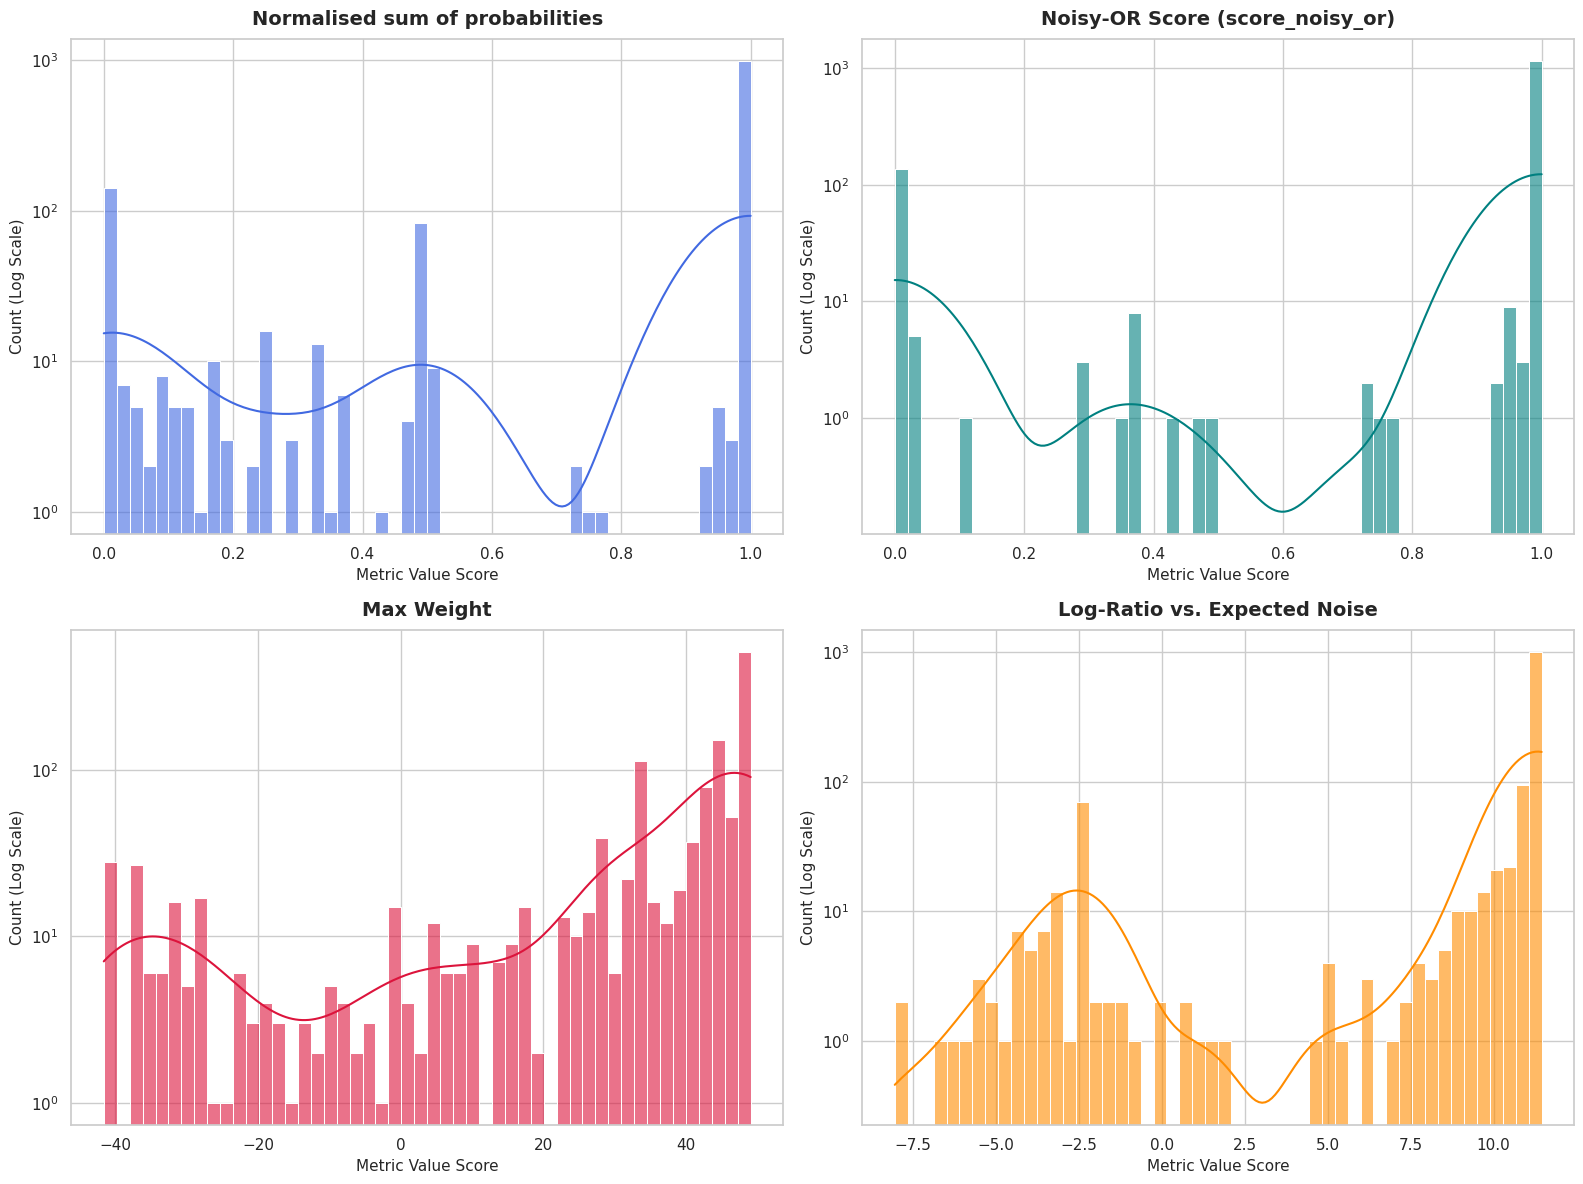

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for the charts
sns.set_theme(style="whitegrid")


def plot_score_distributions(df, log_scale_y=True):
    """Generates a 2x2 grid of histogram plots for the calculated aggregation metrics."""
    # List out your core structural score metrics and their human-readable titles
    metrics = [
        ("match_density", "Normalised sum of probabilities", "royalblue"),
        ("score_noisy_or", "Noisy-OR Score (score_noisy_or)", "teal"),
        ("max_w", "Max Weight", "crimson"),
        (
            "score_prob_expected_ratio",
            "Log-Ratio vs. Expected Noise",
            "darkorange",
        ),
    ]

    # Initialize the 2x2 subplot canvas
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
    axes = axes.flatten()  # Flatten into a 1D array for straightforward looping

    for ax, (col_name, title, color) in zip(axes, metrics):
        if col_name not in df.columns:
            ax.text(
                0.5,
                0.5,
                f"Column '{col_name}'\nnot found in DataFrame",
                ha="center",
                va="center",
                fontsize=12,
                color="gray",
            )
            ax.set_title(title, fontsize=14, fontweight="bold")
            continue

        # Drop NaNs and infinite values for stable distribution plotting
        clean_series = df[col_name].dropna()
        clean_series = clean_series[~np.isinf(clean_series)]

        if clean_series.empty:
            ax.text(
                0.5,
                0.5,
                "No valid numeric data",
                ha="center",
                va="center",
                fontsize=12,
                color="gray",
            )
            ax.set_title(title, fontsize=14, fontweight="bold")
            continue

        # Plot the structural distribution curve and histograms
        sns.histplot(
            data=clean_series,
            ax=ax,
            bins=50,
            kde=True,
            color=color,
            edgecolor="white",
            alpha=0.6,
        )

        # Apply log scale on Y-axis to reveal tiny counts of genuine matches
        if log_scale_y:
            ax.set_yscale("log")
            ax.set_ylabel("Count (Log Scale)", fontsize=11)
        else:
            ax.set_ylabel("Count (Linear Scale)", fontsize=11)

        # Standardise labels and presentation
        ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
        ax.set_xlabel("Metric Value Score", fontsize=11)

    plt.tight_layout()
    plt.show()


# --- Execute the Plotting Engine ---
# Toggle log_scale_y=False if you prefer standard linear counting charts
plot_score_distributions(agg_df, log_scale_y=True)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Define Ground Truth
# Assumes a true entity match means both records belong to the same UAI cluster
agg_df["is_true_match"] = (agg_df["uai_l"] == agg_df["uai_r"]).astype(int)

# 2. Define the Scores to Evaluate
score_cols = [
    "match_density",
    "max_w",
    "score_noisy_or",
    "score_prob_expected_ratio",
]

# Dictionary to hold the final evaluation summaries for each score metric
evaluation_results = {}

for score_col in score_cols:
    print(f"Evaluating metrics for score column: {score_col}")

    # Generate 30 evenly spaced thresholds between min and max of this score
    min_score = agg_df[score_col].min()
    max_score = agg_df[score_col].max()
    thresholds = np.linspace(min_score, max_score, 30)

    bin_records = []

    for i, thresh in enumerate(thresholds):
        # Predict 1 if score >= threshold, else 0
        y_pred = (agg_df[score_col] >= thresh).astype(int)
        y_true = agg_df["is_true_match"]

        # Calculate metrics (zero_division handling prevents warnings on empty bins)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())

        bin_records.append(
            {
                "bin_index": i + 1,
                "threshold": thresh,
                "precision": p,
                "recall": r,
                "f1_score": f1,
                "true_positives": tp,
                "false_positives": fp,
            }
        )

    # Convert results for this specific score to a DataFrame
    evaluation_results[score_col] = pd.DataFrame(bin_records)

# --- 3. Example: How to View the Output ---
# To view the 30-bin performance chart for your new ratio metric:
print("\n--- 30-Bin Performance Table for match_density ---")
print(
    evaluation_results["score_prob_expected_ratio"].to_string(
        index=False, formatters={c: "{:,.4f}".format for c in ["threshold"]}
    )
)


Evaluating metrics for score column: match_density
Evaluating metrics for score column: max_w
Evaluating metrics for score column: score_noisy_or
Evaluating metrics for score column: score_prob_expected_ratio

--- 30-Bin Performance Table for match_density ---
 bin_index threshold  precision   recall  f1_score  true_positives  false_positives
         1   -8.0459   0.705971 1.000000  0.827647             934              389
         2   -7.3736   0.707040 1.000000  0.828381             934              387
         3   -6.7013   0.707576 1.000000  0.828749             934              386
         4   -6.0290   0.708112 1.000000  0.829117             934              385
         5   -5.3567   0.709726 1.000000  0.830222             934              382
         6   -4.6844   0.711890 1.000000  0.831701             934              378
         7   -4.0121   0.717358 1.000000  0.835420             934              368
         8   -3.3398   0.721578 0.998929  0.837899             933 

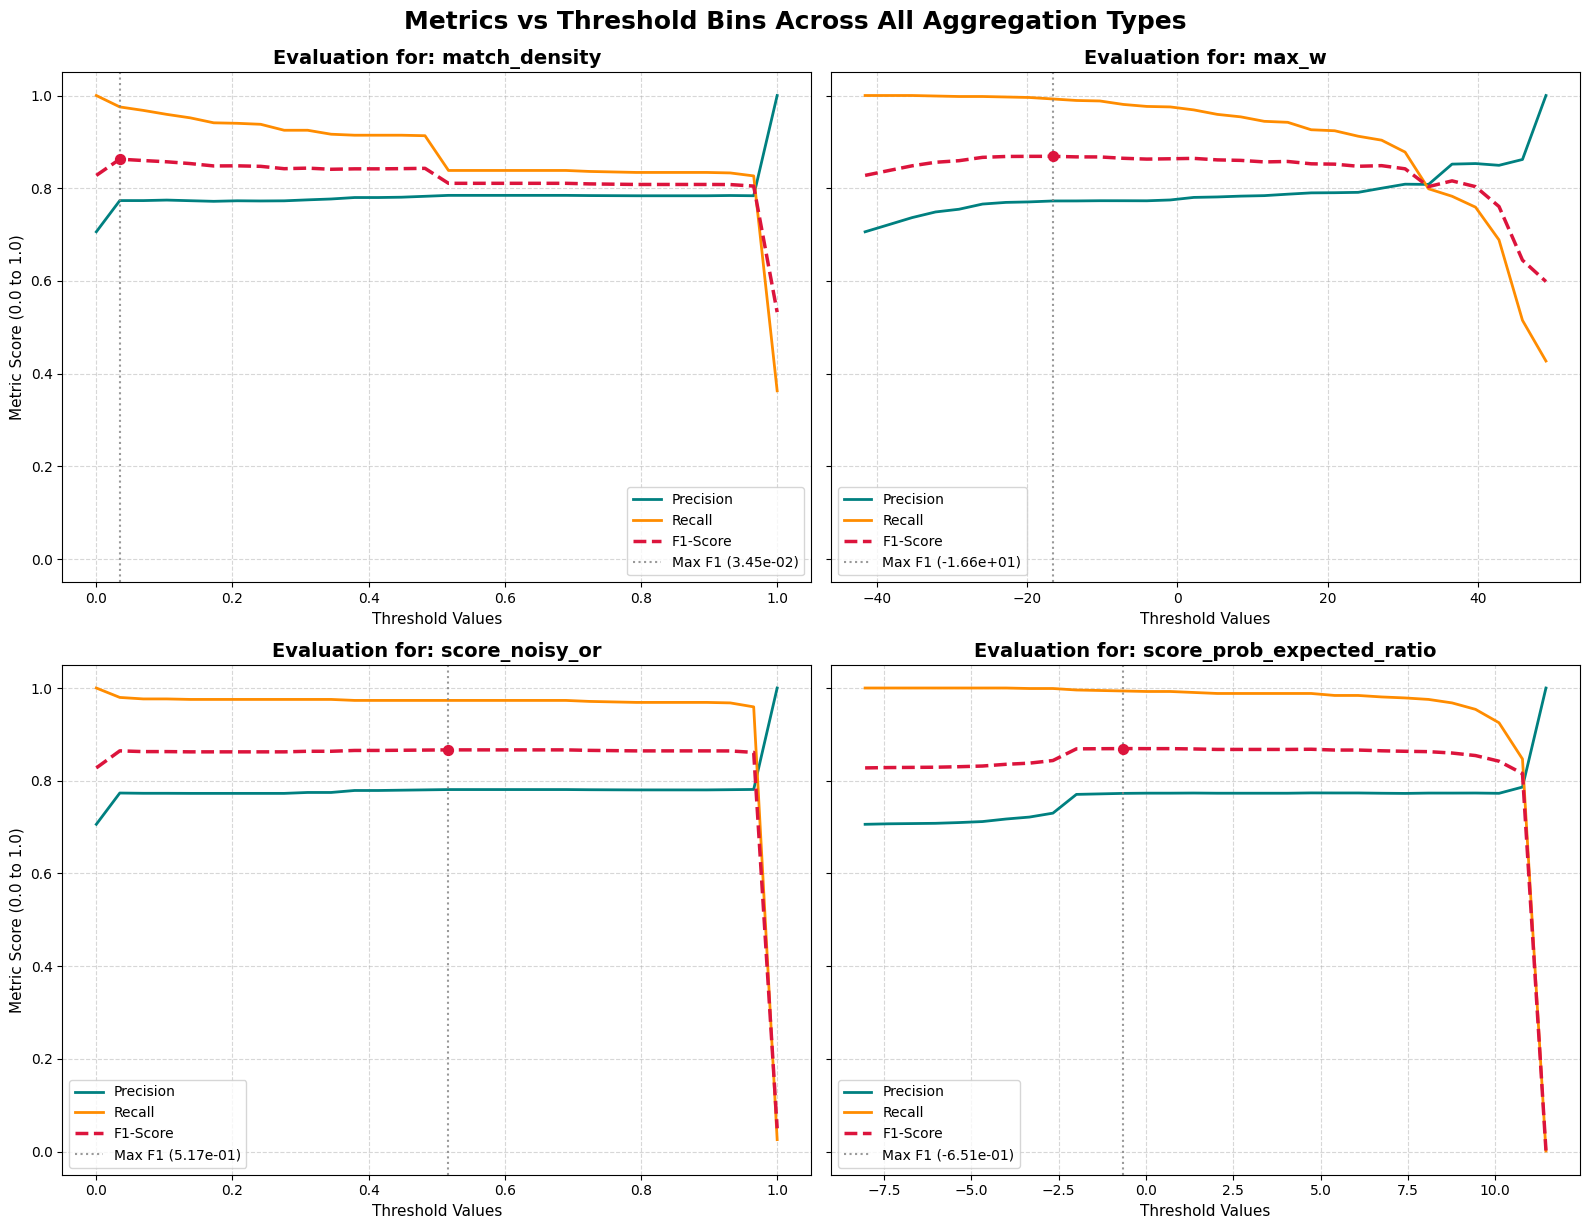

In [ ]:
import matplotlib.pyplot as plt

# Define the scores to plot
score_cols = ["match_density", "max_w", "score_noisy_or", "score_prob_expected_ratio"]

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Flatten into a 1D array for easy looping

for idx, score_col in enumerate(score_cols):
    ax = axes[idx]

    # Get the 30-bin results dataframe for this score
    res_df = evaluation_results[score_col]

    # Plot Precision, Recall, and F1-score
    ax.plot(
        res_df["threshold"],
        res_df["precision"],
        label="Precision",
        color="teal",
        linewidth=2,
    )
    ax.plot(
        res_df["threshold"],
        res_df["recall"],
        label="Recall",
        color="darkorange",
        linewidth=2,
    )
    ax.plot(
        res_df["threshold"],
        res_df["f1_score"],
        label="F1-Score",
        color="crimson",
        linewidth=2.5,
        linestyle="--",
    )

    # Highlight the peak F1-score threshold
    best_idx = res_df["f1_score"].idxmax()
    best_thresh = res_df.loc[best_idx, "threshold"]
    best_f1 = res_df.loc[best_idx, "f1_score"]

    ax.axvline(
        x=best_thresh,
        color="gray",
        linestyle=":",
        alpha=0.8,
        label=f"Max F1 ({best_thresh:.2e})",
    )
    ax.scatter(
        best_thresh, best_f1, color="crimson", s=50, zorder=5
    )  # Dot on the max F1 point

    # Subplot styling
    ax.set_title(f"Evaluation for: {score_col}", fontsize=14, weight="bold")
    ax.set_xlabel("Threshold Values", fontsize=11)
    if idx % 2 == 0:
        ax.set_ylabel("Metric Score (0.0 to 1.0)", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", fontsize=10)
    ax.set_ylim(-0.05, 1.05)

# Adjust layout and render
plt.tight_layout()
plt.suptitle(
    "Metrics vs Threshold Bins Across All Aggregation Types",
    fontsize=18,
    weight="bold",
    y=1.02,
)
plt.show()


Correlation Matrix:
                           match_density  score_prob_expected_ratio     max_w  \
match_density                   1.000000                   0.816612  0.721974   
score_prob_expected_ratio       0.816612                   1.000000  0.884766   
max_w                           0.721974                   0.884766  1.000000   
score_noisy_or                  0.796105                   0.945782  0.911709   

                           score_noisy_or  
match_density                    0.796105  
score_prob_expected_ratio        0.945782  
max_w                            0.911709  
score_noisy_or                   1.000000  


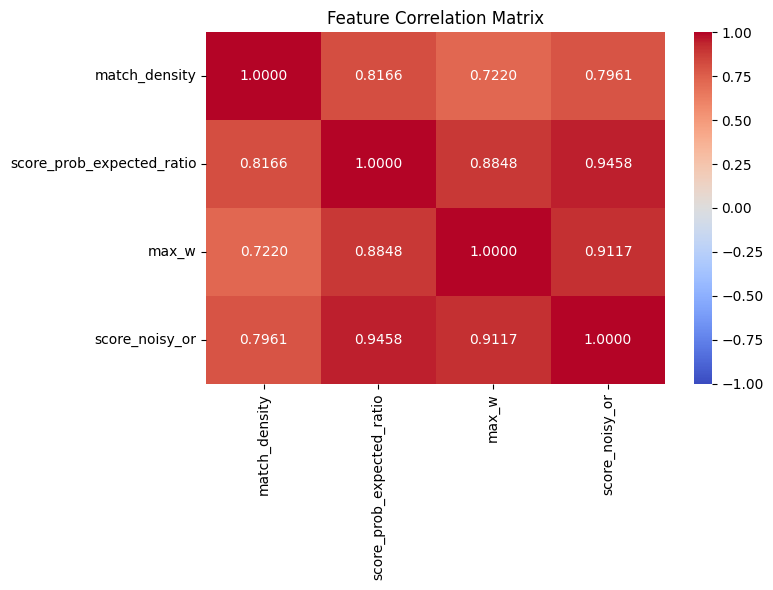

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the specific target columns from your DataFrame
target_columns = ['match_density', 'score_prob_expected_ratio', 'max_w', 'score_noisy_or']
corr_matrix = agg_df[target_columns].corr(method='pearson')

# 2. Print the text matrix to the console
print("Correlation Matrix:")
print(corr_matrix)

# 3. Optional: Create a clean visual heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
